## Imports

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import shap
from imblearn.over_sampling import SMOTE

In [2]:
DATA_PATH = '/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv'

## EDA

In [3]:
dataset = pd.read_csv(DATA_PATH)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
dataset.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
dataset['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [7]:
# Check for zero and negative values in the "amount" column
print(f"Zero values: {(dataset['amount'] == 0).sum()}")
print(f"Negative values: {(dataset['amount'] < 0).sum()}")
print(f"Min value: {dataset['amount'].min()}")
print(f"Max value: {dataset['amount'].max()}")

Zero values: 16
Negative values: 0
Min value: 0.0
Max value: 92445516.64


In [8]:
# Skewness before transformation
original_skewness = stats.skew(dataset['amount'].to_numpy())
print(f"Original Skewness: {original_skewness}")

Original Skewness: 30.99394217560625


In [9]:
# Apply log transformation (using log1p due to the presence of zero values => log1p(x) = Ln(1 + x))
log_amount = np.log1p(dataset['amount'])
log_skewness = stats.skew(log_amount)
print(f"Log-Transformed Skewness: {log_skewness}")

Log-Transformed Skewness: -0.5550181895761241


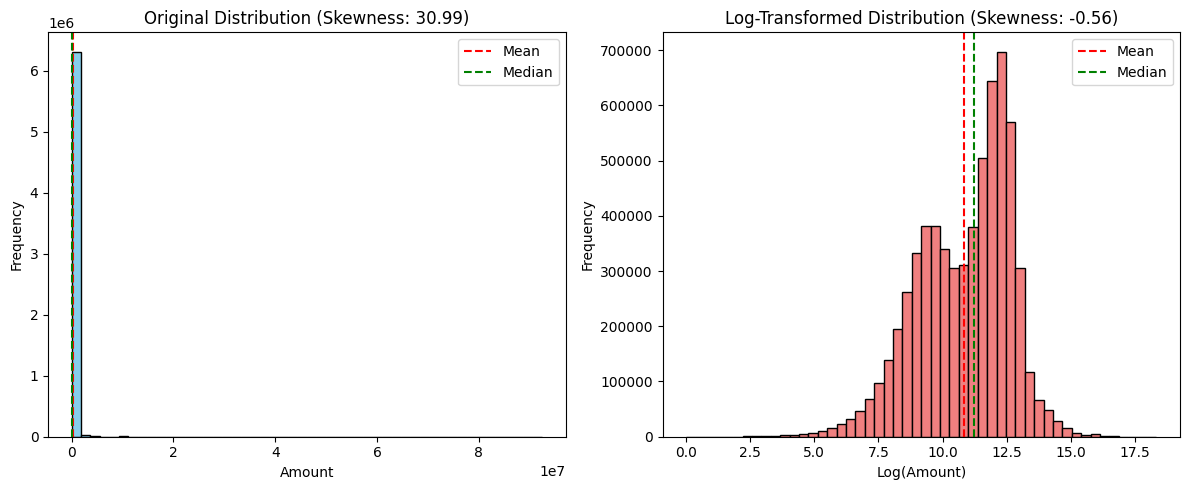

In [10]:
# Visualizion before and after transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original distribution
axes[0].hist(dataset['amount'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Original Distribution (Skewness: {original_skewness:.2f})')
axes[0].axvline(dataset['amount'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(dataset['amount'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Log-transformed distribution
axes[1].hist(log_amount, bins=50, edgecolor='black', color='lightcoral')
axes[1].set_xlabel('Log(Amount)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Log-Transformed Distribution (Skewness: {log_skewness:.2f})')
axes[1].axvline(log_amount.mean(), color='red', linestyle='--', label='Mean')
axes[1].axvline(log_amount.median(), color='green', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

>**This shows that the "amount" feature, due to its skewness, requires logarithmic scaling**

## Data Cleaning and Feature Engineering